<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 47 · Probability &amp; Distributions Case Studies</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Probability Distribution Framework 🗺️</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">A field guide to the thirteen case studies ahead. This notebook draws the whole distribution gallery in one place, contrasts PMF vs PDF vs CDF, and shows how mean and variance set a distribution's shape, the vocabulary for choosing the right model for real data.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":10,"axes.spines.top":False,"axes.spines.right":False})
AMBER="#d97706"; TEAL="#0d9488"; INDIGO="#4f46e5"
print("ready")

ready


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">DEMO 1 · THE DISCRETE GALLERY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Six counting distributions</div>
<div style="color:#4a5578;margin-top:6px">The six discrete distributions of Part VI, each a PMF (probability mass on whole numbers). Bernoulli and binomial count successes; geometric and negative binomial count trials to a target; Poisson counts rare events; hypergeometric draws without replacement.</div>
</div>

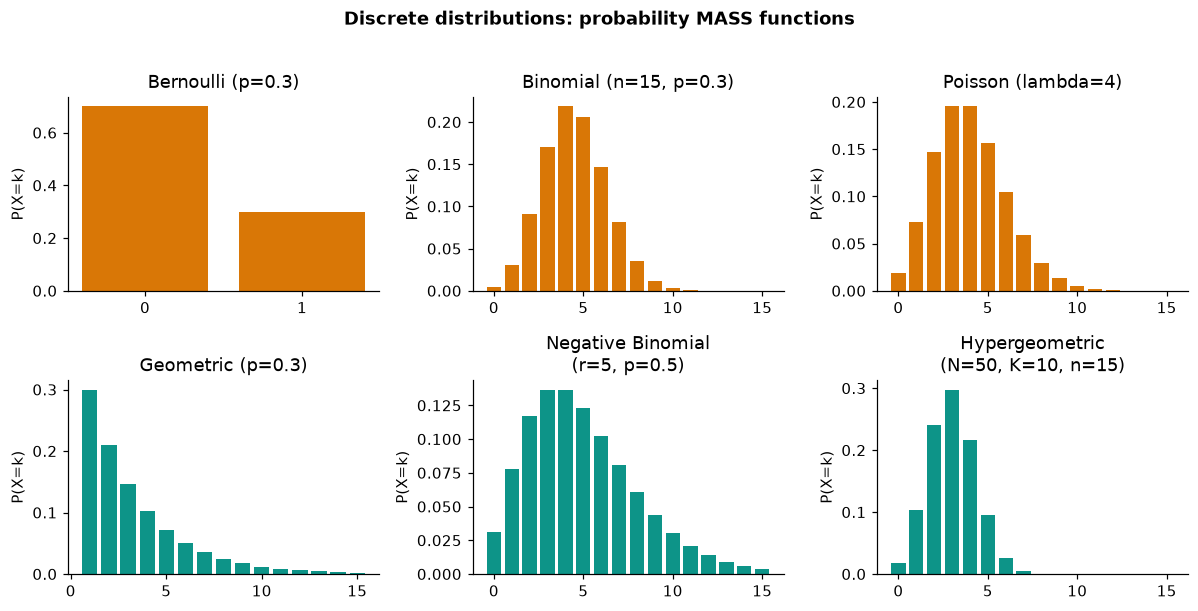

In [2]:
fig,axes=plt.subplots(2,3,figsize=(11,5.4))
k=np.arange(0,16)
axes[0,0].bar([0,1],[0.7,0.3],color=AMBER); axes[0,0].set_title("Bernoulli (p=0.3)"); axes[0,0].set_xticks([0,1])
axes[0,1].bar(k, stats.binom.pmf(k,15,0.3),color=AMBER); axes[0,1].set_title("Binomial (n=15, p=0.3)")
axes[0,2].bar(k, stats.poisson.pmf(k,4),color=AMBER); axes[0,2].set_title("Poisson (lambda=4)")
kg=np.arange(1,16)
axes[1,0].bar(kg, stats.geom.pmf(kg,0.3),color=TEAL); axes[1,0].set_title("Geometric (p=0.3)")
axes[1,1].bar(k, stats.nbinom.pmf(k,5,0.5),color=TEAL); axes[1,1].set_title("Negative Binomial\n(r=5, p=0.5)")
axes[1,2].bar(k, stats.hypergeom.pmf(k,50,10,15),color=TEAL); axes[1,2].set_title("Hypergeometric\n(N=50, K=10, n=15)")
for a in axes.ravel(): a.set_ylabel("P(X=k)")
fig.suptitle("Discrete distributions: probability MASS functions", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()

Each bar is an exact probability, P(X = k). Together they cover almost every counting question: one trial, many trials, waiting for a success, rare events, and sampling without replacement. Chapters 48&ndash;53 fit each to a real dataset.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">DEMO 2 · THE CONTINUOUS GALLERY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Smooth curves over a range</div>
<div style="color:#4a5578;margin-top:6px">Continuous distributions use a probability DENSITY function; probability is area under the curve. The normal is symmetric; the exponential and gamma are right-skewed models of time and positive quantities.</div>
</div>

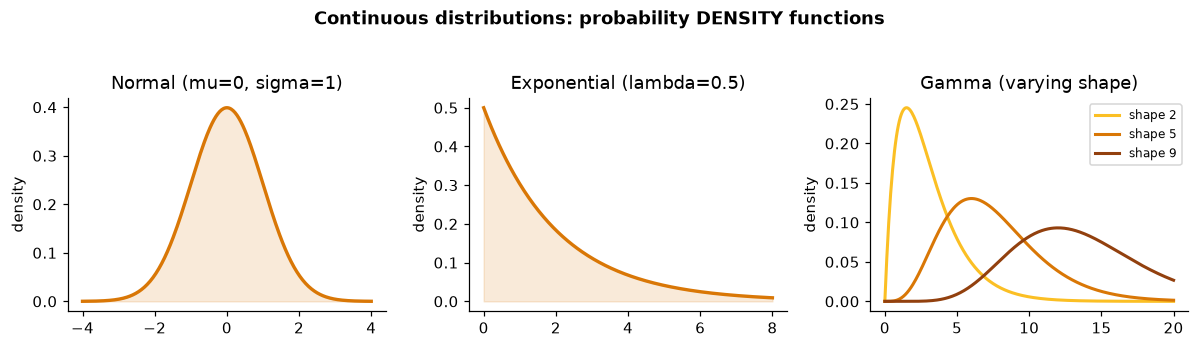

In [3]:
fig,axes=plt.subplots(1,3,figsize=(11,3))
xs=np.linspace(-4,4,300)
axes[0].plot(xs, stats.norm.pdf(xs),color=AMBER,lw=2.2); axes[0].fill_between(xs,stats.norm.pdf(xs),color=AMBER,alpha=0.15); axes[0].set_title("Normal (mu=0, sigma=1)")
xe=np.linspace(0,8,300)
axes[1].plot(xe, stats.expon.pdf(xe,scale=2),color=AMBER,lw=2.2); axes[1].fill_between(xe,stats.expon.pdf(xe,scale=2),color=AMBER,alpha=0.15); axes[1].set_title("Exponential (lambda=0.5)")
xg=np.linspace(0,20,300)
for sh,c in [(2,"#fbbf24"),(5,AMBER),(9,"#92400e")]: axes[2].plot(xg, stats.gamma.pdf(xg,sh,scale=1.5),lw=2,color=c,label=f"shape {sh}")
axes[2].set_title("Gamma (varying shape)"); axes[2].legend(fontsize=8)
for a in axes: a.set_ylabel("density")
fig.suptitle("Continuous distributions: probability DENSITY functions", y=1.04, fontweight="bold")
plt.tight_layout(); plt.show()

Here the y-axis is density, not probability, and the area under a stretch of curve gives the probability of landing in that range. Chapters 54&ndash;56 fit the normal, exponential, and gamma to exam scores, hardware lifespans, and rainfall.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">DEMO 3 · PMF vs PDF vs CDF</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Three views of one distribution</div>
<div style="color:#4a5578;margin-top:6px">The CDF, P(X <= x), works for both discrete and continuous variables and rises from 0 to 1. It answers 'how much probability is at or below this value', the basis of percentiles and tail risks.</div>
</div>

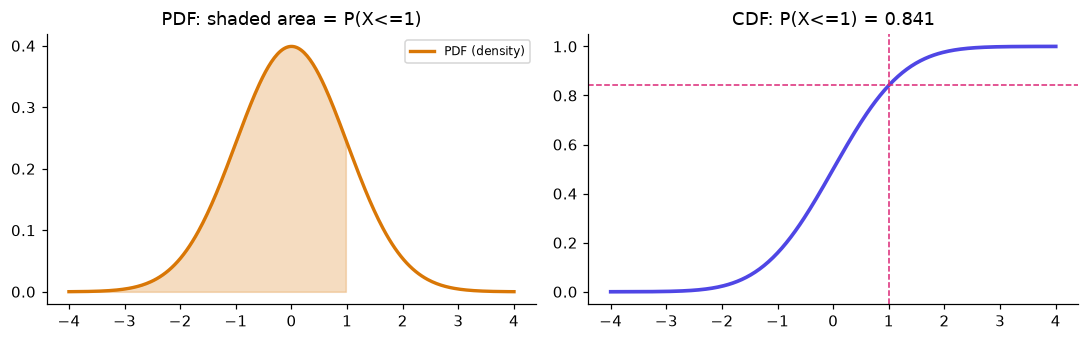

In [4]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(10,3.2))
xs=np.linspace(-4,4,300)
a1.plot(xs, stats.norm.pdf(xs),color=AMBER,lw=2.2,label="PDF (density)")
m=xs<=1; a1.fill_between(xs[m],stats.norm.pdf(xs[m]),color=AMBER,alpha=0.25)
a1.set_title("PDF: shaded area = P(X<=1)"); a1.legend(fontsize=8)
a2.plot(xs, stats.norm.cdf(xs),color=INDIGO,lw=2.4)
a2.axhline(stats.norm.cdf(1),color="#db2777",ls="--",lw=1); a2.axvline(1,color="#db2777",ls="--",lw=1)
a2.set_title(f"CDF: P(X<=1) = {stats.norm.cdf(1):.3f}")
plt.tight_layout(); plt.show()

The shaded PDF area on the left equals the CDF height on the right, both give P(X &le; 1) = 0.841. Discrete distributions have the same CDF idea as a staircase. Every case study uses the PMF/PDF to see the shape and the CDF to compute a cumulative probability.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">DEMO 4 · MEAN &amp; VARIANCE AS SHAPE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Independent vs linked</div>
<div style="color:#4a5578;margin-top:6px">For the normal, mean and variance move independently. For the Poisson they are LINKED (mean = variance = lambda), so a busier process is also a more variable one.</div>
</div>

In [5]:
for lam in [2,5,10]:
    d=stats.poisson(lam)
    print(f"Poisson(lambda={lam:2d}): mean={d.mean():.1f}, variance={d.var():.1f}  (mean == variance)")
print()
for mu,sd in [(0,1),(0,3),(5,1)]:
    print(f"Normal(mu={mu}, sigma={sd}): mean={mu}, variance={sd**2}  (set independently)")

Poisson(lambda= 2): mean=2.0, variance=2.0  (mean == variance)
Poisson(lambda= 5): mean=5.0, variance=5.0  (mean == variance)
Poisson(lambda=10): mean=10.0, variance=10.0  (mean == variance)

Normal(mu=0, sigma=1): mean=0, variance=1  (set independently)
Normal(mu=0, sigma=3): mean=0, variance=9  (set independently)
Normal(mu=5, sigma=1): mean=5, variance=1  (set independently)


This is why the chart lists mean and variance for every distribution: they are the dials that set its center and spread. Sometimes the two are tied together (Poisson, exponential), and sometimes free (normal), a structural fact worth knowing before you model.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🗺️ The road ahead</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You now have the whole gallery in one view. The next thirteen chapters each take one real dataset, choose its distribution, plot the data, compute the probabilities and statistics with Python, and simulate outcomes. Same workflow every time: shape (PMF/PDF), cumulative risk (CDF), and the parameters that drive them.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>